In [2]:
import numpy as np
import pandas as pd
import  seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


<Axes: xlabel='bmi', ylabel='charges'>

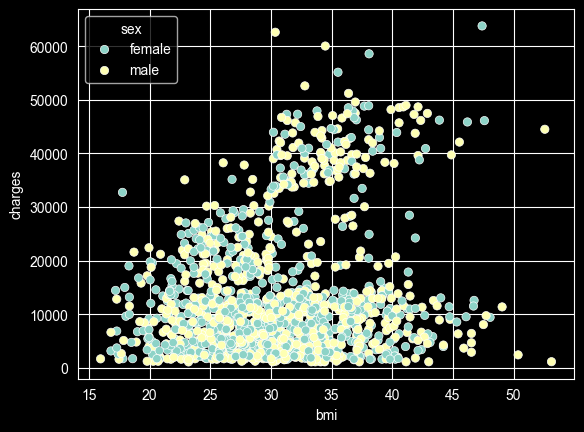

In [6]:

sns.scatterplot(data=df,x=df['bmi'],y=df['charges'],hue=df['sex'])

<Axes: title={'center': 'Correlation Between Numeric Data'}>

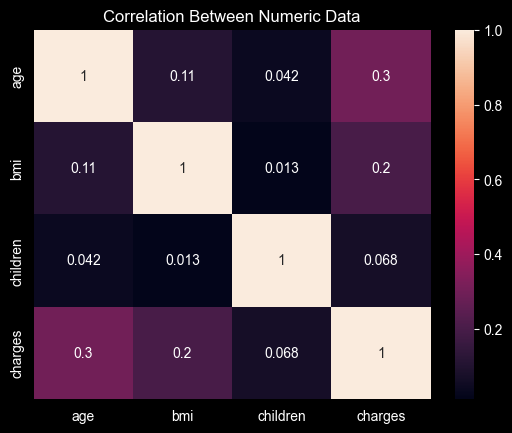

In [7]:
sns.heatmap(data = df.corr(numeric_only=True),annot=True)

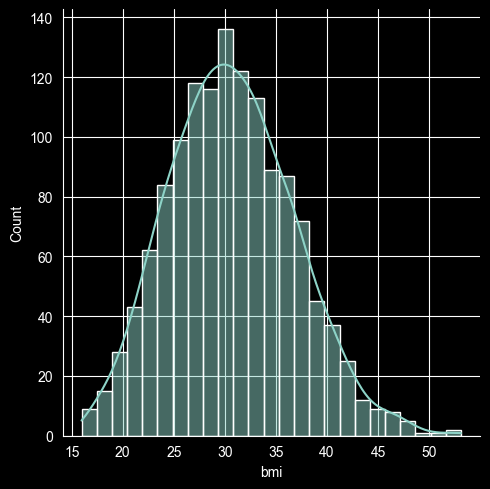

In [8]:

sns.displot(data=df,x=df['bmi'],kde=True);
plt.savefig("BMI Distribution")

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [11]:
df['region'].value_counts()

southeast    364
southwest    325
northwest    324
northeast    324
Name: region, dtype: int64

In [12]:
df = pd.get_dummies(data = df , columns=['sex','smoker','region'],drop_first=True)

In [13]:
df['bmi_smoker']   = df['bmi'] * df['smoker_yes']
df['age2']         = df['age'] ** 2
df['obese_smoker'] = (df['bmi'] >= 30).astype(int) * df['smoker_yes']
df['age_smoker']   = df['age'] * df['smoker_yes']

df['bmi_tier'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                         labels=['under', 'normal', 'overweight', 'obese'])
df = pd.get_dummies(df, columns=['bmi_tier'], drop_first=True)

In [14]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker,age2,obese_smoker,age_smoker,bmi_tier_normal,bmi_tier_overweight,bmi_tier_obese
0,19,27.900,0,16884.92400,0,1,0,0,1,27.9,361,0,19,0,1,0
1,18,33.770,1,1725.55230,1,0,0,1,0,0.0,324,0,0,0,0,1
2,28,33.000,3,4449.46200,1,0,0,1,0,0.0,784,0,0,0,0,1
3,33,22.705,0,21984.47061,1,0,1,0,0,0.0,1089,0,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0,0.0,1024,0,0,0,1,0


In [15]:
X = df.drop('charges',axis=1)

In [16]:
#y = df['charges']
y = np.log(df['charges'])

In [17]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker,age2,obese_smoker,age_smoker,bmi_tier_normal,bmi_tier_overweight,bmi_tier_obese
0,19,27.900,0,0,1,0,0,1,27.90,361,0,19,0,1,0
1,18,33.770,1,1,0,0,1,0,0.00,324,0,0,0,0,1
2,28,33.000,3,1,0,0,1,0,0.00,784,0,0,0,0,1
3,33,22.705,0,1,0,1,0,0,0.00,1089,0,0,1,0,0
4,32,28.880,0,1,0,1,0,0,0.00,1024,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,0,0,0.00,2500,0,0,0,0,1
1334,18,31.920,0,0,0,0,0,0,0.00,324,0,0,0,0,1
1335,18,36.850,0,0,0,0,1,0,0.00,324,0,0,0,0,1
1336,21,25.800,0,0,0,0,0,1,0.00,441,0,0,0,1,0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
df.shape

(1337, 16)

In [23]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.25,random_state=42
)

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, ElasticNet,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [25]:
models = {
    'Linear Regression' : LinearRegression(),
    'Elastic Net'       : ElasticNet(),
    'Random Forest'     : RandomForestRegressor(random_state=42),
    'XGBoost'           : XGBRegressor(random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(random_state=42),
}

In [26]:
param_grids = {
    'Linear Regression': {},
    'Elastic Net': {
        'model__alpha'    : [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__l1_ratio' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'model__max_iter' : [5000, 10000, 20000],
        'model__selection': ['cyclic', 'random']
    },
    'Random Forest': {
        'model__n_estimators'     : [100, 200, 300, 500, 700],
        'model__max_depth'        : [None, 3, 5, 10, 15, 20, 30],
        'model__min_samples_split': [2, 3, 5, 8, 10, 15],
        'model__min_samples_leaf' : [1, 2, 3, 4, 6],
        'model__max_features'     : ['sqrt', 'log2', None],
        'model__bootstrap'        : [True, False]
    },

    'XGBoost': {
        'model__n_estimators'     : [100, 200, 300, 500, 700],
        'model__learning_rate'    : [0.005, 0.01, 0.03, 0.05, 0.1, 0.2],
        'model__max_depth'        : [2, 3, 4, 5, 6, 7, 9],
        'model__subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
        'model__reg_alpha'        : [0, 0.01, 0.1, 1],
        'model__reg_lambda'       : [0.5, 1, 2, 5],
        'model__min_child_weight' : [1, 3, 5, 7]
    },

    'Gradient Boosting': {
        'model__n_estimators'     : [100, 200, 300, 500],
        'model__learning_rate'    : [0.01, 0.05, 0.1, 0.2],
        'model__max_depth'        : [2, 3, 4, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4],
        'model__subsample'        : [0.7, 0.8, 0.9, 1.0],
        'model__max_features'     : ['sqrt', 'log2', None]
    }
}

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV,KFold


In [28]:
best_models = {}
results = {}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    if not param_grids[name]:
            scores = cross_val_score(pipe, X_train, y_train,
                                     cv=cv_strategy, scoring='r2', n_jobs=-1)
            pipe.fit(X_train, y_train)
            best_models[name] = pipe
            results[name]     = scores.mean()
            print(f"\n{name}")
            print("CV R2:", round(scores.mean(), 4))
            print("-" * 95)
            continue


    search = RandomizedSearchCV(
        pipe,
        param_grids[name],
        n_iter=100,
        cv=cv_strategy,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        refit=True,
        error_score='raise'
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    results[name] = search.best_score_

    print(f"\n{name}")
    print("Best Score:", search.best_score_)
    print("Best Params:", search.best_params_)
    print("-"*95)


Linear Regression
CV R2: 0.8123
-----------------------------------------------------------------------------------------------

Elastic Net
Best Score: 0.8122518032263877
Best Params: {'model__selection': 'cyclic', 'model__max_iter': 10000, 'model__l1_ratio': 0.1, 'model__alpha': 0.001}
-----------------------------------------------------------------------------------------------

Random Forest
Best Score: 0.8122890022145587
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 3, 'model__max_features': 'log2', 'model__max_depth': 15, 'model__bootstrap': True}
-----------------------------------------------------------------------------------------------

XGBoost
Best Score: 0.8178569303574503
Best Params: {'model__subsample': 1.0, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 100, 'model__min_child_weight': 7, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}
---------------

In [29]:
best_name = max(results, key=results.get)
final_model = best_models[best_name]

In [30]:
best_name

'Gradient Boosting'

In [31]:
y_pred = final_model.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Final Model:", best_name)
y_pred_actual = np.exp(final_model.predict(X_test))
y_test_actual = np.exp(y_test)

print(f"R2  : {round(r2_score(y_test_actual, y_pred_actual), 4)}")
print(f"MAE : {round(mean_absolute_error(y_test_actual, y_pred_actual), 2)}")

Final Model: Gradient Boosting
R2  : 0.8848
MAE : 2049.26


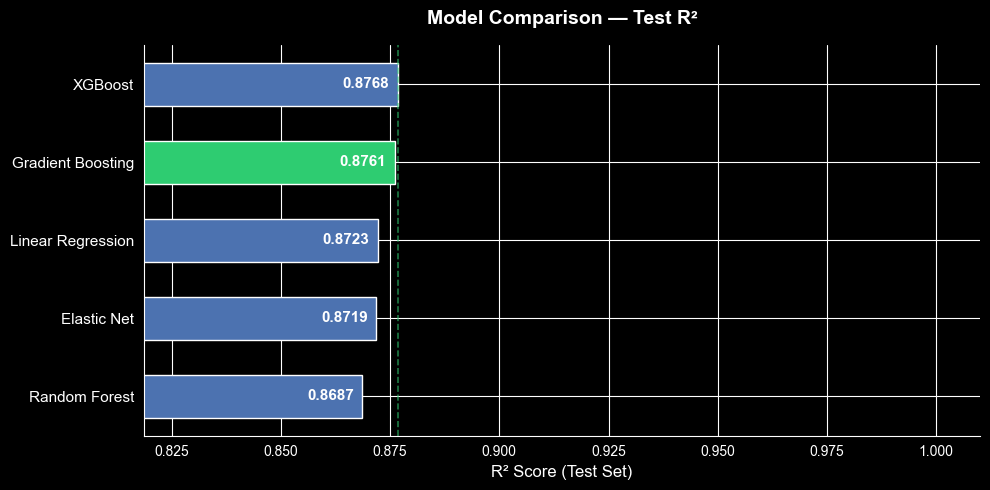

In [33]:
test_scores = {}
for name, model in best_models.items():
    y_pred_i = model.predict(X_test)
    test_scores[name] = round(r2_score(y_test, y_pred_i), 4)


sorted_names = sorted(test_scores, key=test_scores.get)
sorted_scores = [test_scores[n] for n in sorted_names]

colors = ['#4C72B0' if n != best_name else '#2ecc71' for n in sorted_names]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(sorted_names, sorted_scores, color=colors, edgecolor='white', height=0.55)

for bar, score in zip(bars, sorted_scores):
    ax.text(bar.get_width() - 0.002, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', ha='right', color='white',
            fontsize=11, fontweight='bold')

ax.axvline(x=max(sorted_scores), color='#2ecc71', linestyle='--', linewidth=1.2, alpha=0.6)

ax.set_xlabel('R² Score (Test Set)', fontsize=12)
ax.set_title('Model Comparison — Test R²', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(min(sorted_scores) - 0.05, 1.01)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import r2_score

# =========================
# Calculate Scores
# =========================
test_scores = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    test_scores[name] = round(r2_score(y_test, y_pred), 4)

# =========================
# Create DataFrame
# =========================
results_df = pd.DataFrame({
    "Model": list(test_scores.keys()),
    "R2 Score": list(test_scores.values())
})

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=True
)

# =========================
# Best Model
# =========================
best_name = results_df.iloc[-1]["Model"]
best_score = results_df.iloc[-1]["R2 Score"]

# =========================
# Colors
# =========================
results_df["Category"] = results_df["Model"].apply(
    lambda x: "Best Model" if x == best_name else "Other Models"
)

fig = px.bar(
    results_df,
    x="R2 Score",
    y="Model",
    orientation="h",
    text="R2 Score",
    color="Category",

    color_discrete_map={
        "Best Model": "#2ecc71",
        "Other Models": "#4C72B0"
    },

    title="Model Comparison — Test R²"
)

fig.update_traces(
    texttemplate='%{text:.4f}',
    textposition='inside'
)

fig.update_layout(
    template="plotly_white",

    title={
        "x": 0.5
    },

    xaxis_title="R² Score",
    yaxis_title="",

    font=dict(size=14),

    showlegend=False,

    height=500
)

# Best Score Line
fig.add_vline(
    x=best_score,
    line_dash="dash",
    line_color="#2ecc71",
    line_width=2
)

# =========================
# Show Figure
# =========================
fig.show()